In [8]:
pip install scikit_learn pandas numpy matplotlib seaborn 


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Invistico_Airline.csv")
df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [13]:
df["satisfaction"].value_counts(dropna = False)

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [14]:
df.isna().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [15]:
df = df.dropna(axis=0).reset_index(drop = True)

In [16]:
df["Inflight entertainment"] = df["Inflight entertainment"].astype(float)

In [17]:
df["satisfaction"] = OneHotEncoder(drop="first").fit_transform(df[["satisfaction"]]).toarray()
df["Customer Type"] = OneHotEncoder(drop="first").fit_transform(df[["Customer Type"]]).toarray()
df["Type of Travel"] = OneHotEncoder(drop="first").fit_transform(df[["Type of Travel"]]).toarray()
df["Class"] = OneHotEncoder(drop="first").fit_transform(df[["Class"]]).toarray()

In [18]:
df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0.0,65,1.0,1.0,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1.0,0.0,47,1.0,0.0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1.0,0.0,15,1.0,1.0,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1.0,0.0,60,1.0,1.0,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1.0,0.0,70,1.0,1.0,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,1.0,0.0,30,1.0,1.0,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,1.0,0.0,66,1.0,1.0,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,1.0,0.0,10,1.0,1.0,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,1.0,0.0,56,1.0,0.0,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,1.0,0.0,22,1.0,1.0,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


In [19]:
X = df.drop("satisfaction",axis=1)
y = df["satisfaction"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
model = LogisticRegression()
model = model.fit(X_train,y_train)

/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
model.coef_

array([[-3.66880608e-01, -2.47947037e-02, -2.07318715e-01,
        -4.55867930e-01, -3.97587844e-04,  2.23076754e-01,
        -2.51710514e-01, -1.29192344e-02, -2.49236020e-01,
        -2.69598668e-01,  7.38807597e-01,  1.37677878e-01,
         2.51866855e-01,  2.24400625e-01,  1.30761502e-01,
        -9.54202389e-02,  6.79738375e-02, -1.27858267e-01,
         2.49404355e-03,  3.09639380e-03, -7.97339090e-03]])

In [42]:
model.intercept_

array([-0.1901397])

<Axes: xlabel='Inflight entertainment', ylabel='satisfaction'>

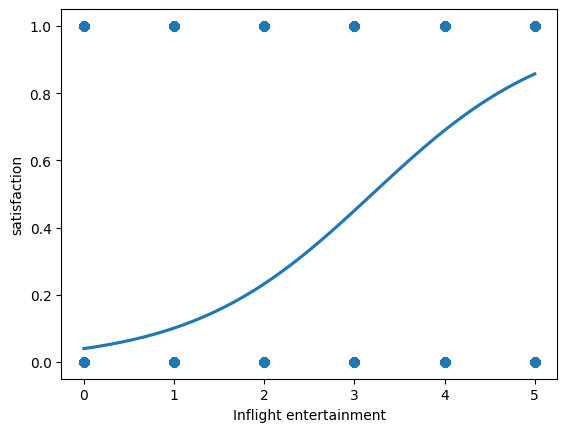

In [16]:
sns.regplot(x ="Inflight entertainment",y="satisfaction",data=df,logistic=True,ci =None)

In [43]:
y_pred = model.predict(X_test)

In [44]:
y_pred

array([1., 0., 0., ..., 0., 0., 0.], shape=(32372,))

In [45]:
model.predict_proba(X_test)

array([[0.23023794, 0.76976206],
       [0.72047418, 0.27952582],
       [0.85647862, 0.14352138],
       ...,
       [0.51830889, 0.48169111],
       [0.65237883, 0.34762117],
       [0.58195995, 0.41804005]], shape=(32372, 2))

In [46]:
model.predict(X_test)

array([1., 0., 0., ..., 0., 0., 0.], shape=(32372,))

In [47]:
print(f"Precision: {metrics.precision_score(y_test,y_pred):.6f}")
print(f"Accuracy: {metrics.accuracy_score(y_test,y_pred):.6f}")
print(f"Recall: {metrics.recall_score(y_test,y_pred):.6f}")
print(f"F1 score: {metrics.f1_score(y_test,y_pred):.6f}")

Precision: 0.768006
Accuracy: 0.777431
Recall: 0.848778
F1 score: 0.806374


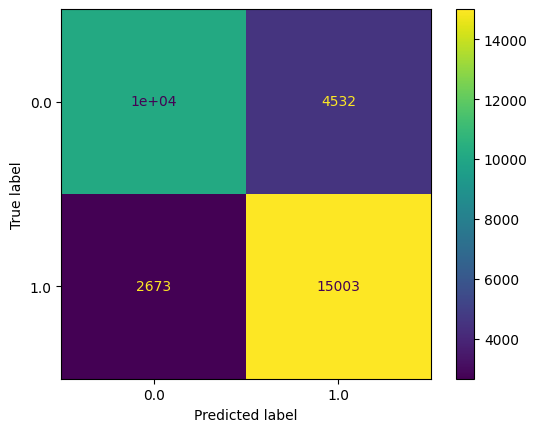

In [22]:
cm = metrics.confusion_matrix(y_test,y_pred,labels = model.classes_)
fig = metrics.ConfusionMatrixDisplay(confusion_matrix =cm,display_labels =model.classes_)
fig.plot()

In [48]:
# ________________Building decision tree_________________ 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

In [49]:
df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0.0,65,1.0,1.0,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1.0,0.0,47,1.0,0.0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1.0,0.0,15,1.0,1.0,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1.0,0.0,60,1.0,1.0,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1.0,0.0,70,1.0,1.0,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,1.0,0.0,30,1.0,1.0,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,1.0,0.0,66,1.0,1.0,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,1.0,0.0,10,1.0,1.0,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,1.0,0.0,56,1.0,0.0,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,1.0,0.0,22,1.0,1.0,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


In [50]:
np.unique(df["Class"])

array([0., 1.])

In [51]:
df["Class"].value_counts()

Class
0.0    71370
1.0    58117
Name: count, dtype: int64

In [52]:
df.isna().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

In [53]:
df.shape

(129487, 22)

In [54]:
df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1.0,0.0,65,1.0,1.0,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1.0,0.0,47,1.0,0.0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1.0,0.0,15,1.0,1.0,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1.0,0.0,60,1.0,1.0,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1.0,0.0,70,1.0,1.0,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,1.0,0.0,30,1.0,1.0,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,1.0,0.0,66,1.0,1.0,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,1.0,0.0,10,1.0,1.0,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,1.0,0.0,56,1.0,0.0,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,1.0,0.0,22,1.0,1.0,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129487 entries, 0 to 129486
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129487 non-null  float64
 1   Customer Type                      129487 non-null  float64
 2   Age                                129487 non-null  int64  
 3   Type of Travel                     129487 non-null  float64
 4   Class                              129487 non-null  float64
 5   Flight Distance                    129487 non-null  int64  
 6   Seat comfort                       129487 non-null  int64  
 7   Departure/Arrival time convenient  129487 non-null  int64  
 8   Food and drink                     129487 non-null  int64  
 9   Gate location                      129487 non-null  int64  
 10  Inflight wifi service              129487 non-null  int64  
 11  Inflight entertainment             1294

In [56]:
# new training set for decision tree
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [57]:
ml = DecisionTreeClassifier(random_state=0)
ml = ml.fit(X_train,y_train)


In [58]:
dt_pred = ml.predict(X_test)

In [59]:
print(f"Precision: {metrics.precision_score(y_test,dt_pred):.6f}")
print(f"Accuracy: {metrics.accuracy_score(y_test,dt_pred):.6f}")
print(f"Recall: {metrics.recall_score(y_test,dt_pred):.6f}")
print(f"F1 score: {metrics.f1_score(y_test,dt_pred):.6f}")

Precision: 0.935663
Accuracy: 0.932998
Recall: 0.942068
F1 score: 0.938855


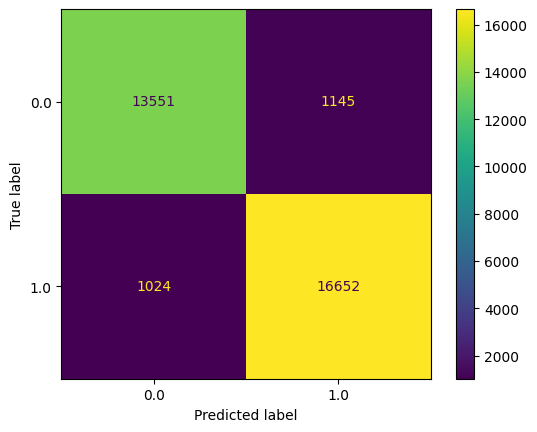

In [35]:
cm = metrics.confusion_matrix(y_test,dt_pred,labels=ml.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ml.classes_)
disp.plot()


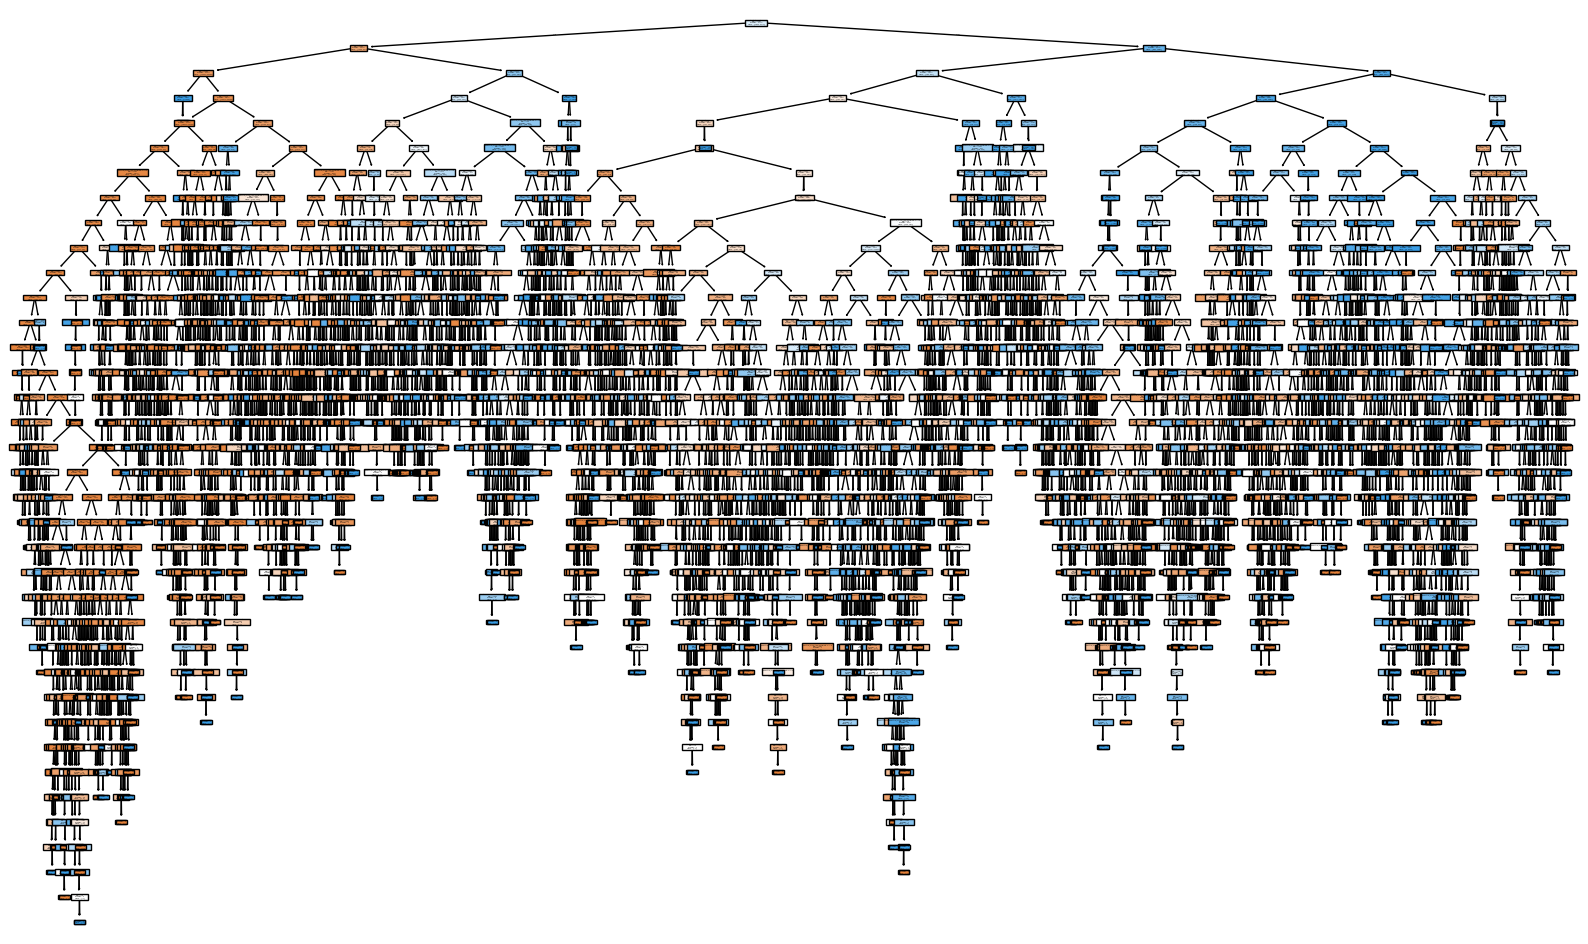

In [36]:
fig, ax = plt.subplots(figsize=(20, 12))
plt.figure = plot_tree(ml,filled=True,feature_names=X.columns,ax=ax)


In [60]:
#Intializing gridsearch
tree_para = {'max_depth':[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
             'min_samples_leaf': [2,3,4,5,6,7,8,9, 10, 15, 20, 50]}

scoring = ['accuracy', 'precision','f1', 'recall']


In [ ]:
tuned_ml = DecisionTreeClassifier(random_state=0)
clf = GridSearchCV(tuned_ml,
                   tree_para,
                   scoring=scoring,
                   cv=5,
                   refit="f1")
clf.fit(X_train,y_train)

In [61]:
clf.best_estimator_

NameError: name 'clf' is not defined

In [62]:
print(f"Best Avg validation Score:{clf.best_score_:.4f}")

NameError: name 'clf' is not defined

NameError: name 'clf' is not defined

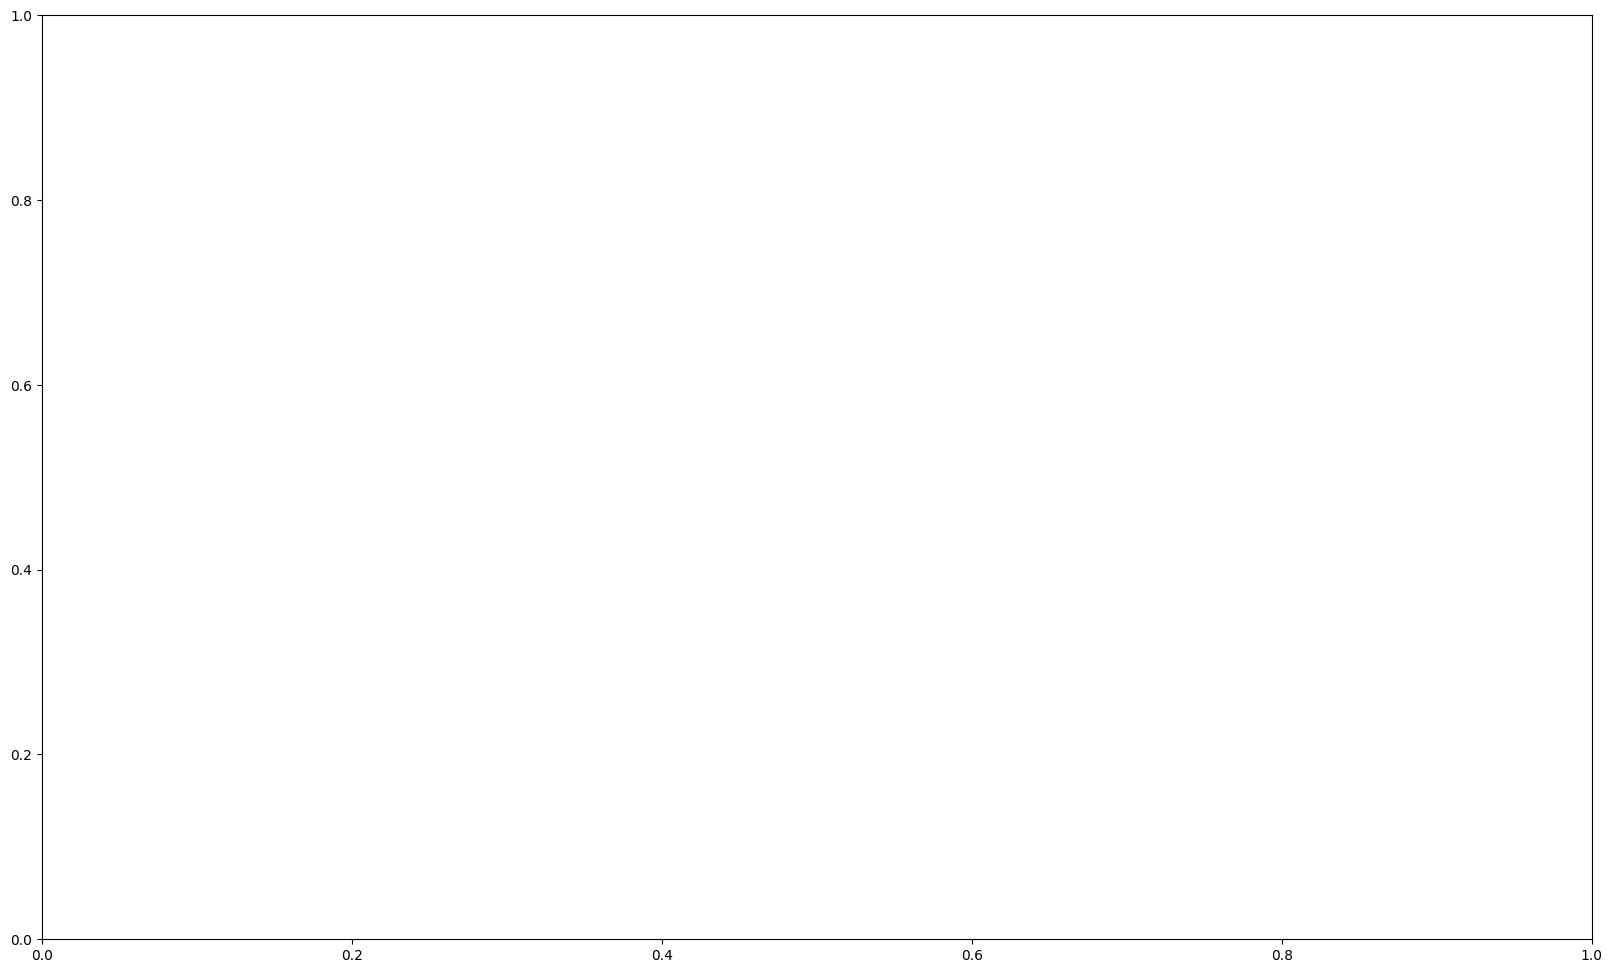

In [63]:
fig, ax = plt.subplots(figsize=(20, 12))
plt.figure = plot_tree(clf.best_estimator_,max_depth=2,filled=True,feature_names=X.columns,ax=ax)


In [64]:
# building random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import PredefinedSplit
import pickle

In [65]:
X_tr,y_tr,X_te,y_te= train_test_split(X,y,test_size=0.25,random_state=0)

In [66]:
cv_params = {'n_estimators' : [50,100], 
              'max_depth' : [10,50],        
              'min_samples_leaf' : [0.5,1], 
              'min_samples_split' : [0.001, 0.01],
              'max_features' : ["sqrt"], 
              'max_samples' : [.5,.9]}

In [67]:
index_split = [0 if x in X_te.index else -1 for x in X_train.index]
cs = PredefinedSplit(index_split)

In [68]:
rf = RandomForestClassifier(random_state=0)

In [69]:

tuned_rf = GridSearchCV(rf,
                   cv_params,
                   cv=cs,
                   refit ="f1",
                   n_jobs=-1,
                   verbose=1)
tuned_rf.fit(X_train,y_train)
                   

Fitting 1 folds for each of 32 candidates, totalling 32 fits


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [10, 50], 'max_features': ['sqrt'], 'max_samples': [0.5, 0.9], 'min_samples_leaf': [0.5, 1], ...}"
,scoring,None
,n_jobs,-1
,refit,'f1'
,cv,"PredefinedSpl...ape=(97115,)))"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [70]:
tuned_rf.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,50
,min_samples_split,0.001
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
rf_opt = RandomForestClassifier(n_estimators = 50,max_samples=0.9,max_features="sqrt",max_depth=50,
                                min_samples_leaf=0.001,random_state=0)

In [72]:
rf_opt.fit(X_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,50
,min_samples_split,2
,min_samples_leaf,0.001
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
rf_pred = rf_opt.predict(X_test)

In [74]:
print(f"Precision: {metrics.precision_score(y_test,rf_pred):.6f}")
print(f"Accuracy: {metrics.accuracy_score(y_test,rf_pred):.6f}")
print(f"Recall: {metrics.recall_score(y_test,rf_pred):.6f}")
print(f"F1 score: {metrics.f1_score(y_test,rf_pred):.6f}")

Precision: 0.914849
Accuracy: 0.913289
Recall: 0.927529
F1 score: 0.921145


In [75]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [76]:
# ___________________Building XGBoost Model___________________
from xgboost import XGBClassifier
from xgboost import plot_importance

In [80]:
xgb = XGBClassifier(objective="binary:logistic",random_state=0)

In [81]:
gb_params = {
    'max_depth': [4],
    'min_child_weight': [3],
    'learning_rate': [0.1],
    'n_estimators': [5],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

In [82]:
tuned_xgb = GridSearchCV(
    xgb,
    gb_params,
    cv=5,
    scoring=scoring,
    refit="f1")
tuned_xgb.fit(X_train,y_train)
    

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7], 'learning_rate': [0.1], 'max_depth': [4], 'min_child_weight': [3], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [84]:
xgb_pred = tuned_xgb.predict(X_test)

In [85]:
print(f"Precision: {metrics.precision_score(y_test,xgb_pred):.6f}")
print(f"Accuracy: {metrics.accuracy_score(y_test,xgb_pred):.6f}")
print(f"Recall: {metrics.recall_score(y_test,xgb_pred):.6f}")
print(f"F1 score: {metrics.f1_score(y_test,xgb_pred):.6f}")

Precision: 0.860544
Accuracy: 0.887156
Recall: 0.946764
F1 score: 0.901597


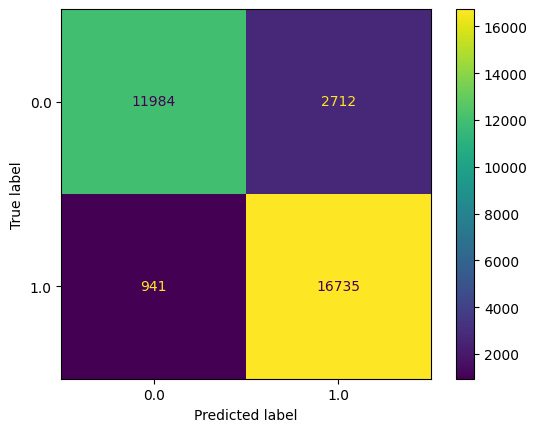

In [86]:
cm = metrics.confusion_matrix(y_test,xgb_pred,labels=ml.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ml.classes_)
disp.plot()


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

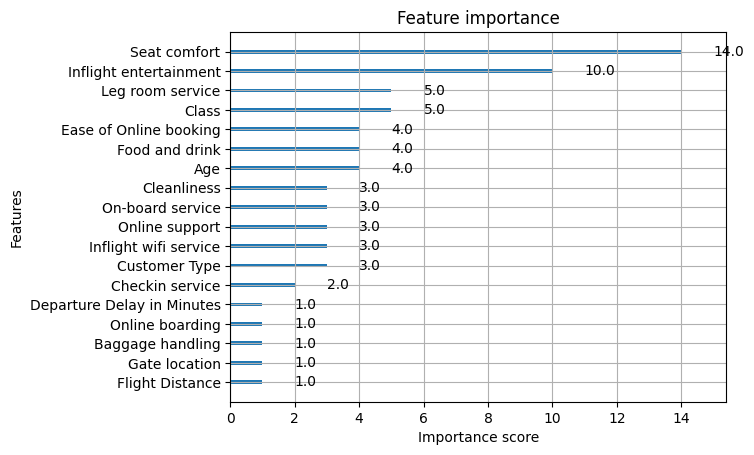

In [88]:
plot_importance(tuned_xgb.best_estimator_)

In [91]:
table = pd.DataFrame({'Model': ["logistic Regression","Decision Tree","Tuned Decision Tree", "Tuned Random Forest", "Tuned XGBoost"],
                      "Precision": [0.768006,0.935663,0.945422,0.914849,0.860544],
                        "Accuracy":[0.777431,0.932998,0.935863,0.913289,0.887156],
                        "Recall": [0.848778,0.942068,0.955197,0.927529,0.946764],
                        "F1 score":[0.806374,0.938855,0.940864,0.921145,0.901597]
                     }
                    )
table

,Model,Precision,Accuracy,Recall,F1 score
0,logistic Regression,0.768006,0.777431,0.848778,0.806374
1,Decision Tree,0.935663,0.932998,0.942068,0.938855
2,Tuned Decision Tree,0.945422,0.935863,0.955197,0.940864
3,Tuned Random Forest,0.914849,0.913289,0.927529,0.921145
4,Tuned XGBoost,0.860544,0.887156,0.946764,0.901597


[]

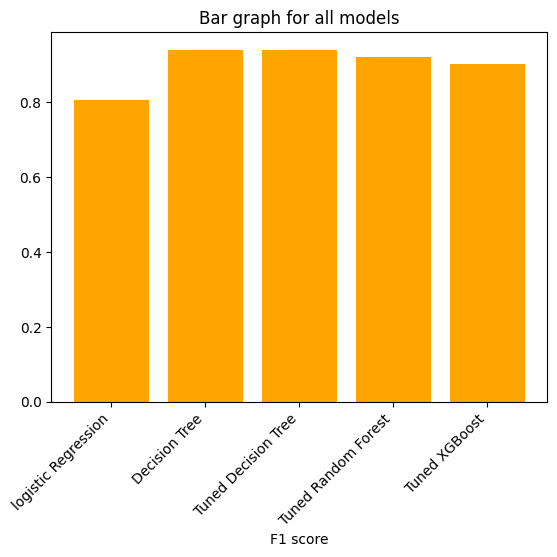

In [ ]:
plt.bar(table["Model"],table["F1 score"],color="orange")
plt.xticks(rotation=45,ha="right")
plt.ylabel("F1 score")
plt.title("Bar graph for all models")
plt.plot()